# Python Sets

A **set** is an unordered collection of UNIQUE items. Three defining properties:

1. **Unordered** — no index numbers, no guaranteed display order, can't be accessed by position.
2. **Unchangeable elements, but a changeable set** — you can add/remove items freely, but each item itself must be IMMUTABLE (so a set can't contain a list or another set — only hashable types like numbers, strings, and tuples).
3. **Unique** — duplicates are automatically collapsed; a value can appear at most once.

This notebook covers creating, accessing, adding/removing, the full mathematical set-operation toolkit, copying, subset/superset checks, `frozenset`, nested sets, and set comprehensions.

## Creating a Set

Curly braces `{}` (non-empty only!), or the `set()` constructor.

In [ ]:
sample_set = {'Mark', 'Jessa', 25, 75.25}   # heterogeneous is fine

print(sample_set)



book_set = set(("Harry Potter", "Angels and Demons", "Atlas Shrugged"))

print(book_set)

print(type(book_set))

### Creating a Set From a List (Deduplication)

In [ ]:
number_list = [20, 30, 20, 30, 50, 30]

sample_set = set(number_list)

print(sample_set)

### Sets Cannot Contain Mutable Elements

In [ ]:
try:

    bad_set = {'Mark', 'Jessa', [35, 78, 92]}

except TypeError as e:

    print("TypeError:", e)

### Empty Set — a Common Trap

`{}` does NOT create an empty set — it creates an empty DICTIONARY. Always use `set()` for an empty set.

In [ ]:
empty_set = set()

print(type(empty_set))



empty_dict = {}

print(type(empty_dict))

## Accessing Items

No indexing — the only way to see a set's items is to iterate them (in whatever order the set happens to store them, which is NOT the insertion order).

In [ ]:
book_set = {"Harry Potter", "Angels and Demons", "Atlas Shrugged"}

for book in book_set:

    print(book)

### Checking Membership With `in`

In [ ]:
book_set = {"Harry Potter", "Angels and Demons", "Atlas Shrugged"}

if 'Harry Potter' in book_set:

    print("Book exists in the book set")

else:

    print("Book doesn't exist in the book set")



print("A Man called Ove" in book_set)

## Length of a Set

In [ ]:
book_set = {"Harry Potter", "Angels and Demons", "Atlas Shrugged"}

print(len(book_set))

## Adding Items

`add()` for ONE item; `update()` for MULTIPLE items at once (pass an iterable).

In [ ]:
book_set = {'Harry Potter', 'Angels and Demons'}



book_set.add('The God of Small Things')

print(book_set)



book_set.update(['Atlas Shrugged', 'Ulysses'])

print(book_set)

## Removing Items

| Method | Behavior |
|---|---|
| `remove(x)` | Removes `x`; raises `KeyError` if `x` isn't present |
| `discard(x)` | Removes `x`; does NOT raise an error if `x` isn't present |
| `pop()` | Removes and returns an ARBITRARY item (sets have no 'first' or 'last') |
| `clear()` | Empties the set |
| `del set_name` | Deletes the set variable entirely |

In [ ]:
color_set = {'red', 'orange', 'yellow', 'white', 'black'}



color_set.remove('yellow')

print(color_set)



color_set.discard('white')

print(color_set)



deleted_item = color_set.pop()

print("popped:", deleted_item)



color_set.clear()

print(color_set)

### `remove()` vs. `discard()`

In [ ]:
color_set = {'red', 'orange', 'white', 'black'}



color_set.discard('yellow')   # not present - silently does nothing

print(color_set)



try:

    color_set.remove('yellow')   # not present - raises KeyError

except KeyError as e:

    print("KeyError:", e)

## Set Operations

All standard mathematical set operations, each available as both an OPERATOR and an equivalent METHOD.

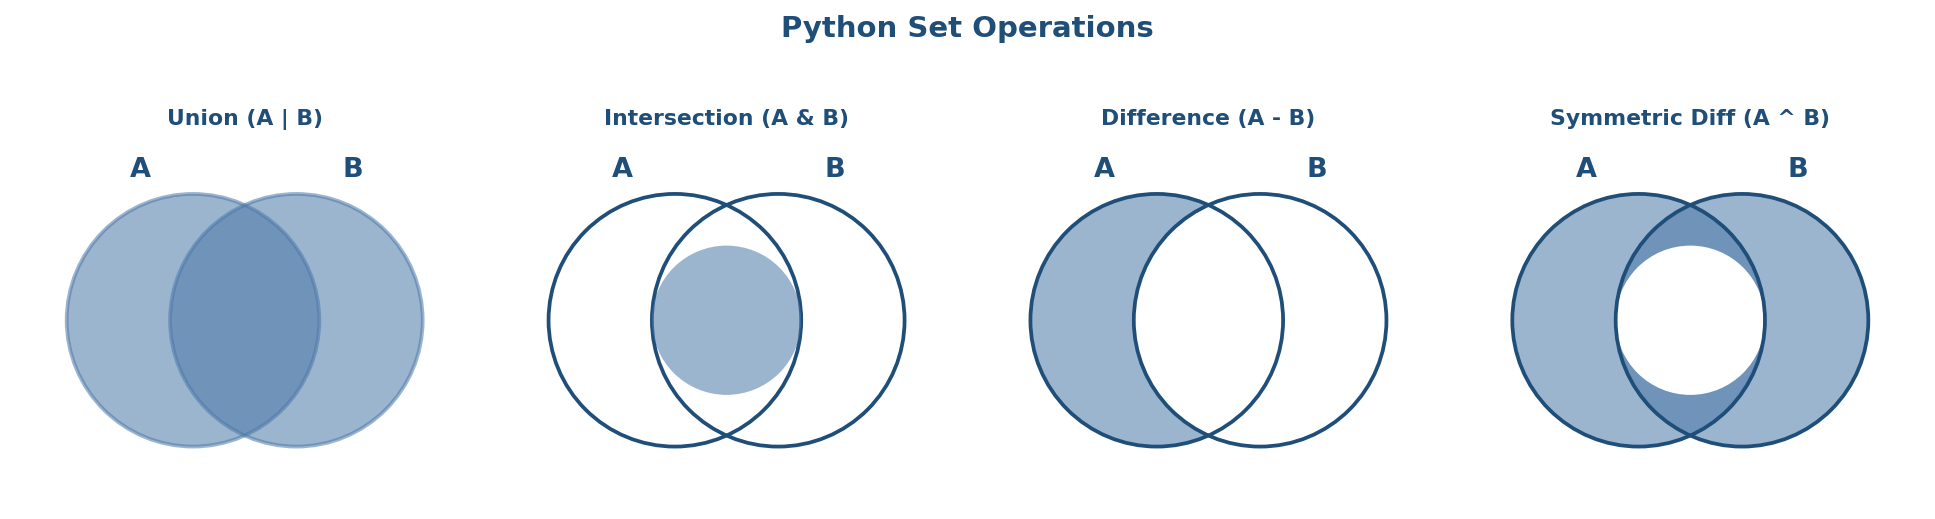

### Union — everything from both sets

In [ ]:
color_set = {'violet', 'indigo', 'blue', 'green', 'yellow'}

remaining_colors = {'indigo', 'orange', 'red'}



print(color_set | remaining_colors)

print(color_set.union(remaining_colors))

### Intersection — only what's shared

In [ ]:
color_set = {'violet', 'indigo', 'blue', 'green', 'yellow'}

remaining_colors = {'indigo', 'orange', 'red'}



print(color_set & remaining_colors)

print(color_set.intersection(remaining_colors))

#### `intersection_update()` — the in-place version

`intersection()` returns a NEW set, leaving the original untouched. `intersection_update()` instead modifies the ORIGINAL set in place and returns `None`.

In [ ]:
color_set = {'violet', 'indigo', 'blue', 'green', 'yellow'}

remaining_colors = {'indigo', 'orange', 'red'}



common_colors = color_set.intersection(remaining_colors)

print(common_colors)

print(color_set)   # unchanged



color_set.intersection_update(remaining_colors)

print(color_set)   # NOW changed

### Difference — in the first set but NOT the second

In [ ]:
color_set = {'violet', 'indigo', 'blue', 'green', 'yellow'}

remaining_colors = {'indigo', 'orange', 'red'}



print(color_set - remaining_colors)

print(color_set.difference(remaining_colors))

#### `difference_update()` — the in-place version

In [ ]:
color_set = {'violet', 'indigo', 'blue', 'green', 'yellow'}

remaining_colors = {'indigo', 'orange', 'red'}



new_set = color_set.difference(remaining_colors)

print(new_set)

print(color_set)   # unchanged



color_set.difference_update(remaining_colors)

print(color_set)   # NOW changed

### Symmetric Difference — in exactly ONE of the two sets, not both

In [ ]:
color_set = {'violet', 'indigo', 'blue', 'green', 'yellow'}

remaining_colors = {'indigo', 'orange', 'red'}



print(color_set ^ remaining_colors)

print(color_set.symmetric_difference(remaining_colors))

#### `symmetric_difference_update()` — the in-place version

In [ ]:
color_set = {'violet', 'indigo', 'blue', 'green', 'yellow'}

remaining_colors = {'indigo', 'orange', 'red'}



color_set.symmetric_difference_update(remaining_colors)

print(color_set)

## Copying a Set

Just like lists, assignment (`=`) does NOT copy — it shares the same object. Use `.copy()` or `set()` for a genuine independent copy.

In [ ]:
color_set = {'violet', 'blue', 'green', 'yellow'}



color_set2 = color_set.copy()   # genuine copy

color_set3 = set(color_set)     # also a genuine copy

color_set4 = color_set          # NOT a copy - same object



color_set.add('indigo')



print('Original set:      ', color_set)

print('Copy using copy():  ', color_set2)   # unaffected

print('Copy using set():   ', color_set3)   # unaffected

print('"Copy" using =:     ', color_set4)   # CHANGED too - same object as original

## Subset and Superset

`issubset()` — is EVERY item of this set also in the other one? `issuperset()` — does this set contain EVERY item of the other one? (Mirror operations.)

In [ ]:
color_set1 = {'violet', 'indigo', 'blue', 'green', 'yellow', 'orange', 'red'}

color_set2 = {'indigo', 'orange', 'red'}



print(color_set2.issubset(color_set1))

print(color_set1.issubset(color_set2))



print(color_set2.issuperset(color_set1))

print(color_set1.issuperset(color_set2))

## Checking If Two Sets Are Disjoint

`isdisjoint()` — `True` if the sets share NO elements at all.

In [ ]:
color_set1 = {'violet', 'blue', 'yellow', 'red'}

color_set2 = {'orange', 'red'}

color_set3 = {'green', 'orange'}



print(color_set2.isdisjoint(color_set1))   # False - both contain 'red'

print(color_set3.isdisjoint(color_set1))   # True - no shared items

## Sorting a Set

There's no real concept of a 'sorted set' — sets are inherently unordered. `sorted()` returns a genuinely ordered LIST; converting that back to a set (as shown for illustration) immediately throws the order away again, since sets never preserve order regardless of how they were built.

In [ ]:
set1 = {20, 4, 6, 10, 8, 15}

sorted_list = sorted(set1)

print(sorted_list)   # this IS reliably ordered - it's a list



sorted_set = set(sorted_list)

print(sorted_set)    # order is NOT guaranteed here - it's a set again

## Built-in Functions: `all()`, `any()`, `max()`, `min()`

Same semantics as for lists and tuples.

In [ ]:
set1 = {1, 2, 3, 4}

set2 = {0, 2, 4, 6, 8}

set4 = {True, False}



print('all() with all true:', all(set1))

print('any() with all true:', any(set1))

print('all() with one zero:', all(set2))

print('any() with one zero:', any(set2))

print('all() with one False:', all(set4))

print('any() with one False:', any(set4))

In [ ]:
set1 = {2, 4, 6, 10, 8, 15}

set2 = {'ABC', 'abc'}



print(max(set1))

print(max(set2))   # lowercase sorts AFTER uppercase in ASCII

print(min(set1))

print(min(set2))

## `frozenset` — an Immutable Set

Same set semantics, but LOCKED — no `add()`/`remove()`/`update()` allowed after creation.

In [ ]:
rainbow = ('violet', 'indigo', 'blue', 'green', 'yellow', 'orange', 'red')

f_set = frozenset(rainbow)

print(f_set)

In [ ]:
f_set = frozenset(('violet', 'indigo', 'blue'))

try:

    f_set.add('red')

except AttributeError as e:

    print("AttributeError:", e)

Non-mutating operations (union, intersection, difference, symmetric_difference) work perfectly fine on `frozenset` — only the IN-PLACE `_update()` variants are unavailable, since those inherently require mutation.

In [ ]:
colorset1 = frozenset(('violet', 'indigo', 'blue', 'green'))

colorset2 = frozenset(('blue', 'green', 'red'))



print('Union:', colorset1.union(colorset2))

print('Intersection:', colorset1.intersection(colorset2))

print('Difference (1-2):', colorset1.difference(colorset2))

print('Difference (2-1):', colorset2.difference(colorset1))

print('Symmetric difference:', colorset1.symmetric_difference(colorset2))

## Nested Sets

A regular set can't contain another set directly (sets aren't hashable), but it CAN contain a `frozenset` — since frozensets ARE hashable, being immutable.

In [ ]:
rainbow = ('violet', 'indigo', 'blue', 'green', 'yellow', 'orange', 'red')

other_colors = ('white', 'black', 'pink')



nested_set = set((frozenset(rainbow), frozenset(other_colors)))



for sample_set in nested_set:

    print(sample_set)

## Set Comprehension

`{expression for variable in inputSet if condition}` — curly braces, no colon (a colon would make it a dict comprehension instead).

In [ ]:
square_set = {var ** 2 for var in range(1, 10) if var % 2 == 0}

print(square_set)

## When to Use a Set

- **Removing duplicates** from a collection, fast and automatically.
- **Membership testing** — checking `x in my_set` is O(1) on average (hash-table lookup), versus O(n) for a list — much faster for large collections checked repeatedly.
- **Mathematical set operations** — union, intersection, difference are exactly what you want when comparing two groups of items.

## Practice Exercises

1. Given two sets of student names in Math class and Science class, find students taking BOTH classes, students taking ONLY Math, and the combined roster of all students.
2. Remove duplicate values from `values = [4, 2, 7, 2, 4, 9, 7, 1]` and print the result sorted ascending.
3. Write a function `has_common_element(a, b)` that returns `True` if two lists share at least one value — implement it using sets and `isdisjoint()` for efficiency.
4. Create a `frozenset` of the numbers 1-5 and confirm it can be used as a dictionary key (build a small dict with it).
5. Using set comprehension, build a set of all vowels found in the sentence `"the quick brown fox jumps over the lazy dog"`.

### Exercise 1 solution

In [ ]:
math_students = {"Alice", "Bob", "Charlie", "Diana"}

science_students = {"Bob", "Diana", "Eve", "Frank"}



print("Both classes:", math_students & science_students)

print("Only Math:", math_students - science_students)

print("All students:", math_students | science_students)

### Exercise 2 solution

In [ ]:
values = [4, 2, 7, 2, 4, 9, 7, 1]

unique_sorted = sorted(set(values))

print(unique_sorted)

### Exercise 3 solution

In [ ]:
def has_common_element(a, b):

    return not set(a).isdisjoint(b)



print(has_common_element([1, 2, 3], [3, 4, 5]))

print(has_common_element([1, 2, 3], [4, 5, 6]))

### Exercise 4 solution

In [ ]:
f = frozenset([1, 2, 3, 4, 5])

lookup = {f: "first five numbers"}

print(lookup[f])

### Exercise 5 solution

In [ ]:
sentence = "the quick brown fox jumps over the lazy dog"

vowels = {char for char in sentence if char in 'aeiou'}

print(vowels)